In [9]:
import pandas as pd

df = pd.read_csv("amazon_reviews.csv.csv")

print(df.shape)
print(df.columns.tolist())

(34660, 21)
['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username']


C:\Users\Rutwik\AppData\Local\Temp\ipykernel_6892\2482902953.py:3: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("amazon_reviews.csv.csv")


# Dataset info :
Total Records: 34,660
Total Columns: 21
# Important Columns:
reviews,rating
reviews.text
reviews.title
reviews.didPurchase
brand
name

# Keep Only Useful Columns: 

In [10]:
df_reviews = df[['reviews.rating', 'reviews.text']]

print(df_reviews.head())
print(df_reviews.shape)

   reviews.rating                                       reviews.text
0             5.0  This product so far has not disappointed. My c...
1             5.0  great for beginner or experienced person. Boug...
2             5.0  Inexpensive tablet for him to use and learn on...
3             4.0  I've had my Fire HD 8 two weeks now and I love...
4             5.0  I bought this for my grand daughter when she c...
(34660, 2)


# Remove Missing Reviews:

In [11]:
df_reviews = df_reviews.dropna()

print("After Cleaning:")
print(df_reviews.shape)

After Cleaning:
(34626, 2)


# Sentiment Analysis:

In [12]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df_reviews['Sentiment'] = df_reviews['reviews.text'].apply(get_sentiment)

df_reviews.head()

,reviews.rating,reviews.text,Sentiment
0,5.0,This product so far has not disappointed. My c...,Positive
1,5.0,great for beginner or experienced person. Boug...,Positive
2,5.0,Inexpensive tablet for him to use and learn on...,Positive
3,4.0,I've had my Fire HD 8 two weeks now and I love...,Positive
4,5.0,I bought this for my grand daughter when she c...,Positive


# Count Sentiments:

In [13]:
sentiment_counts = df_reviews['Sentiment'].value_counts()

print(sentiment_counts)

Sentiment
Positive    31130
Neutral      2000
Negative     1496
Name: count, dtype: int64


# Create Visualization:

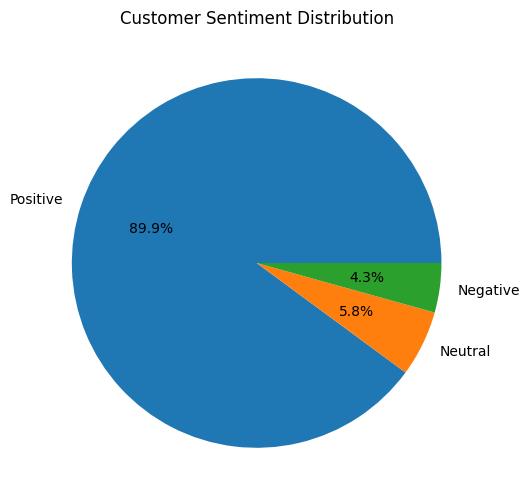

In [14]:
import matplotlib.pyplot as plt

sentiment_counts = df_reviews['Sentiment'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title('Customer Sentiment Distribution')

plt.savefig('customer_sentiment.png', bbox_inches='tight')

plt.show()

# Key Findings

- Most customer reviews are positive.
- Nearly 90% of reviews express customer satisfaction.
- Only a small percentage of reviews are negative.
- Positive customer experiences dominate the dataset.
- Customer sentiment analysis helps businesses understand customer satisfaction levels.